In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the main listings data
df = pd.read_csv('/Users/mynimbus/Library/Mobile Documents/com~apple~CloudDocs/GitHub Uploads/Solve-with-GiGi/EDA/Airbnb/dataset.csv')

# Preview the first few rows
df.head()

- Columns like price, room_type, neighbourhood, availability_365, rating, etc. are rich for analysis.
- Some columns like last_review, bedrooms, baths, and license need cleaning or conversion.
- Looks like id is being read in scientific notation — we’ll fix that too.


In [6]:
# Dataset shape
print("Shape:", df.shape)

# Column data types and non-null counts
print("\nInfo:")
df.info()

# Summary statistics for numeric columns
print("\nDescribe:")
df.describe()

# Count of missing values
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

Shape: (20770, 22)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20770 entries, 0 to 20769
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20770 non-null  float64
 1   name                            20770 non-null  object 
 2   host_id                         20770 non-null  int64  
 3   host_name                       20770 non-null  object 
 4   neighbourhood_group             20770 non-null  object 
 5   neighbourhood                   20763 non-null  object 
 6   latitude                        20763 non-null  float64
 7   longitude                       20763 non-null  float64
 8   room_type                       20763 non-null  object 
 9   price                           20736 non-null  float64
 10  minimum_nights                  20763 non-null  float64
 11  number_of_reviews               20763 non-null  float64
 12  last_r

#### 🧩 Dataset Size
- 20,770 rows × 22 columns — good volume for rich EDA.

#### Missing Values
- Only 34 rows have a missing price, and 7 rows are missing multiple critical fields (location, room_type, etc.).
- These are negligible and likely safe to drop.

#### 🧽 Data Type Issues
- d should be a string, not scientific float.
- last_review should be datetime.
- rating, bedrooms, and baths are object, likely due to non-numeric values like "Not specified" or "Studio".
- license might be categorical but has entries like "No License", "Exempt" — needs parsing.

In [7]:
# Drop rows where essential fields are missing
df.dropna(subset=[
    'neighbourhood', 'latitude', 'longitude', 'room_type',
    'price', 'minimum_nights', 'number_of_reviews',
    'last_review', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365',
    'number_of_reviews_ltm'
], inplace=True)

In [9]:
# Fix ID to string (to avoid scientific notation issues)
df['id'] = df['id'].astype(str)

# Convert 'last_review' to datetime
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

# Convert 'rating' to numeric (handle non-numeric like 'Not specified')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Convert 'bedrooms' to numeric (handle 'Studio' etc.)
df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce')

# Convert 'baths' to numeric (handle 'Not specified')
df['baths'] = pd.to_numeric(df['baths'], errors='coerce')

In [10]:
df.isnull().sum().sort_values(ascending=False)

rating                            3752
bedrooms                          1814
baths                               13
name                                 0
beds                                 0
license                              0
number_of_reviews_ltm                0
availability_365                     0
calculated_host_listings_count       0
reviews_per_month                    0
last_review                          0
id                                   0
minimum_nights                       0
price                                0
room_type                            0
longitude                            0
latitude                             0
neighbourhood                        0
neighbourhood_group                  0
host_name                            0
host_id                              0
number_of_reviews                    0
dtype: int64


# 🧪 Step 4: Univariate Analysis 

## 🎯 Objective:
Univariate Analysis helps us understand **one variable at a time** by examining:
- Distribution (for numerical features)
- Frequency/proportion (for categorical features)
- Outliers and data quality issues

This builds a strong foundation for deeper bivariate and multivariate analysis later.


## 🔍 4A. Numerical Features to Analyze

| Column                  | Importance |
|-------------------------|------------|
| `price`                | Key factor in revenue and guest decision-making |
| `rating`               | Indicates guest satisfaction and listing quality |
| `availability_365`     | Measures how often a listing is available |
| `reviews_per_month`    | Reflects booking frequency/demand |
| `number_of_reviews`    | Popularity indicator |
| `minimum_nights`       | Restricts how the property can be booked |
| `bedrooms`, `beds`, `baths` | Define listing capacity and comfort |

### ✅ For each numerical column:
- Histogram + KDE plot (distribution shape)
- Boxplot (outlier detection)
- Summary statistics: mean, median, std, skewness
- (Optional) Log-transform if distribution is highly skewed (e.g., `price`)


## 🧭 4B. Categorical Features to Analyze

| Column                | Importance |
|------------------------|------------|
| `room_type`            | Defines type of accommodation |
| `neighbourhood_group` | Key for location-based pricing trends |
| `neighbourhood`       | Granular geographic distribution |
| `license`             | Indicates regulatory compliance |
| `host_name`, `host_id`| Useful for host-level aggregation (optional) |

### ✅ For each categorical column:
- Frequency counts and bar plots
- Proportion distribution
- Insights on top categories or anomalies


## 🚧 Missing Data Handling Strategy (Relevant Columns)

| Column     | Strategy |
|------------|----------|
| `rating`   | Leave missing (likely no reviews yet) |
| `bedrooms` | Impute with 0 or treat "Studio" separately |
| `baths`    | Impute with median or drop if very few missing |



## 🗂 Final Univariate Plan Overview

### 🧮 Numerical Columns:
- `price`
- `rating`
- `availability_365`
- `reviews_per_month`
- `number_of_reviews`
- `minimum_nights`
- `bedrooms`
- `beds`
- `baths`

### 🔠 Categorical Columns:
- `room_type`
- `neighbourhood_group`
- `neighbourhood`
- `license`


----
### 🔍 Step 1: Univariate Analysis of "price"

📌 Goals:
- Understand the distribution of prices
- Detect outliers
- Assess skewness
- Decide if transformation (like log) is needed

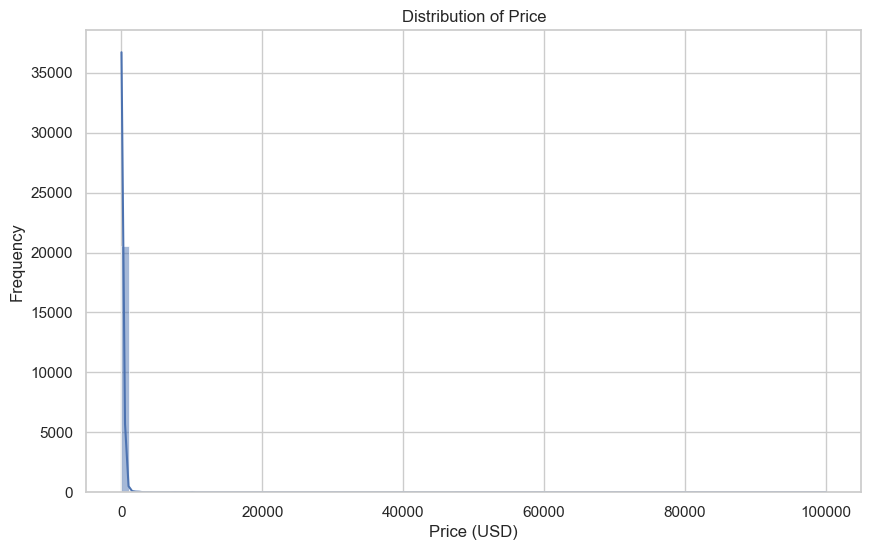

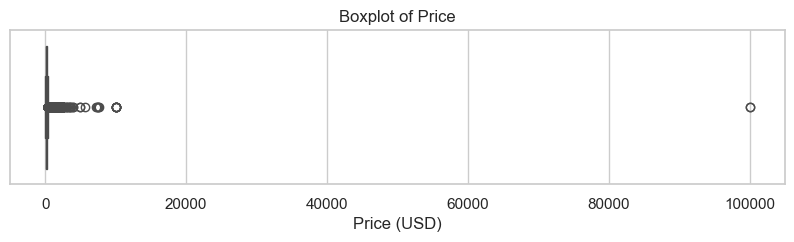

Summary Statistics:
 count     20736.000000
mean        187.714940
std        1023.245124
min          10.000000
25%          80.000000
50%         125.000000
75%         199.000000
max      100000.000000
Name: price, dtype: float64

Skewness of Price: 89.98


In [11]:
# Set plot style
sns.set(style="whitegrid")

# Histogram with KDE
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=100, kde=True)
plt.title("Distribution of Price")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.show()

# Boxplot to detect outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['price'])
plt.title("Boxplot of Price")
plt.xlabel("Price (USD)")
plt.show()

# Summary statistics
price_desc = df['price'].describe()
print("Summary Statistics:\n", price_desc)

# Skewness
skew = df['price'].skew()
print(f"\nSkewness of Price: {skew:.2f}")

🧠 Interpretation of price Distribution

🔢 Summary Stats Recap:
- Mean: $187.7
- Median (50%): $125.0
- Max: $100,000 (!!)
- kewness: 89.98 → extremely right-skewed

📉 Insights:
- The mean > median confirms right-skewness
- Max price is 100,000, clearly an outlier — this heavily distorts the plot
- The histogram appears squeezed to the left, making real data invisible

### 🧹 Step 2: Handle Outliers for Better Visualization

Let’s clip or filter the extreme outliers. We’ll keep prices <= $1000, which is still generous and keeps most listings.

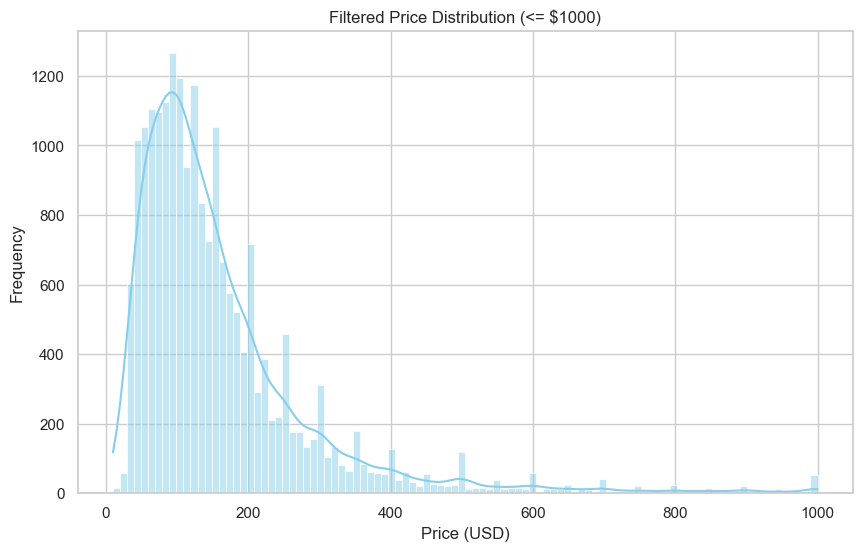

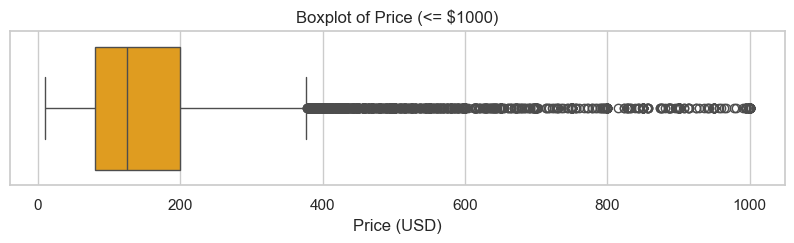

Skewness after filtering: 2.74


In [12]:
# Filter data for listings with price <= 1000
filtered_df = df[df['price'] <= 1000]

# Histogram (filtered)
plt.figure(figsize=(10, 6))
sns.histplot(filtered_df['price'], bins=100, kde=True, color='skyblue')
plt.title("Filtered Price Distribution (<= $1000)")
plt.xlabel("Price (USD)")
plt.ylabel("Frequency")
plt.show()

# Boxplot (filtered)
plt.figure(figsize=(10, 2))
sns.boxplot(x=filtered_df['price'], color='orange')
plt.title("Boxplot of Price (<= $1000)")
plt.xlabel("Price (USD)")
plt.show()

# Updated skewness
print(f"Skewness after filtering: {filtered_df['price'].skew():.2f}")

#### 🔍 After removing outliers (price ≤ $1000):
- Skewness dropped to 2.74, which is still moderately right-skewed
- The histogram should now show a much clearer concentration of realistic prices
- The boxplot is more interpretable and visually meaningful

#### ⚙️ Next Step: Apply Log Transformation?

📌 Why?

A skewness > 1 is typically a good candidate for a log transformation, especially if:
- You plan to use price in regression or correlation analyses later
- You want to normalize the distribution for modeling

/var/folders/6q/mymvn81j1_d0f0htgctb3bmm0000gn/T/ipykernel_2348/1130304043.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['log_price'] = np.log1p(filtered_df['price'])


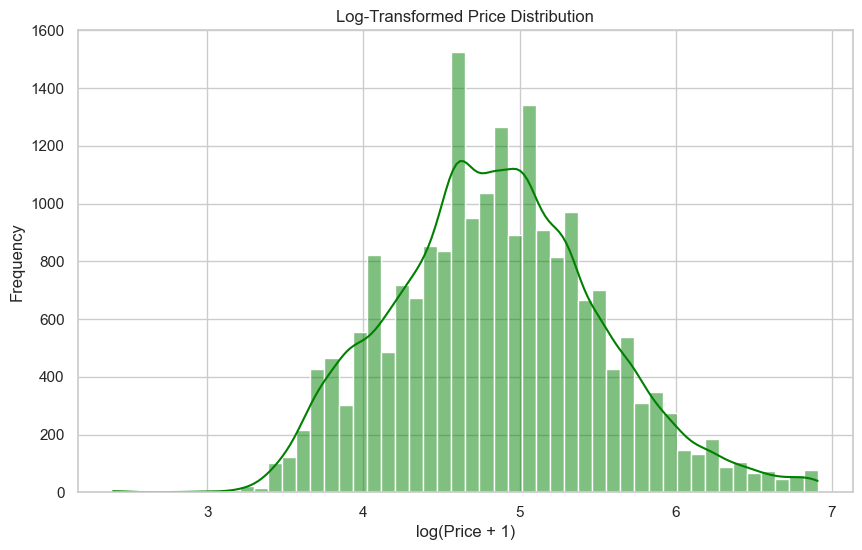

Skewness after log transform: 0.26


In [13]:
# Log transform the filtered price
filtered_df['log_price'] = np.log1p(filtered_df['price'])

# Histogram of log-transformed price
plt.figure(figsize=(10, 6))
sns.histplot(filtered_df['log_price'], bins=50, kde=True, color='green')
plt.title("Log-Transformed Price Distribution")
plt.xlabel("log(Price + 1)")
plt.ylabel("Frequency")
plt.show()

# Skewness after log transform
print(f"Skewness after log transform: {filtered_df['log_price'].skew():.2f}")

- Skewness < 0.5 → distribution is now nearly normal
- Ready for use in modeling or comparisons
- We’ll use both versions:
    - price → for business insights
    - log_price → for statistical or ML tasks

## Univariate analysis for "minimum_nights"

In [14]:
# code to get a feel for the distribution

print(df['minimum_nights'].describe())
print(f"Skewness: {df['minimum_nights'].skew():.2f}")

count    20736.000000
mean        28.564525
std         33.551588
min          1.000000
25%         30.000000
50%         30.000000
75%         30.000000
max       1250.000000
Name: minimum_nights, dtype: float64
Skewness: 18.52


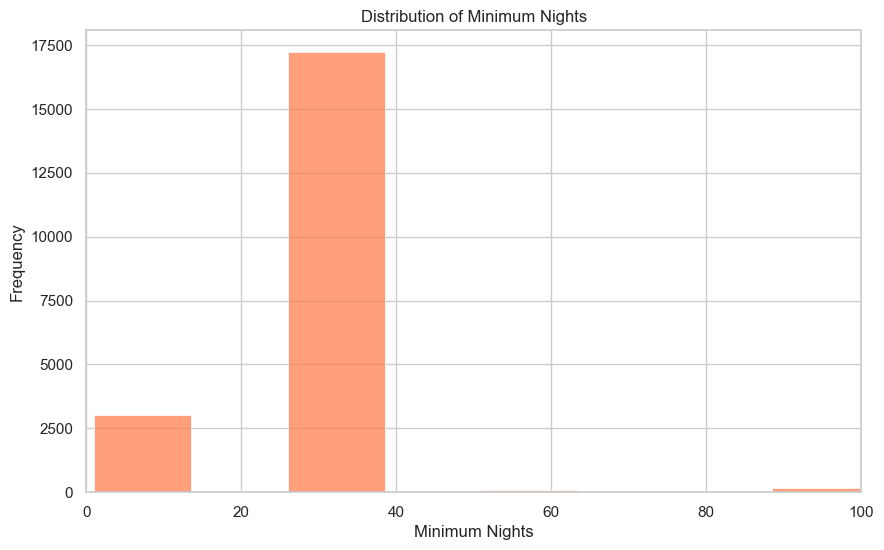

In [15]:
# Check top 1% high values
df['minimum_nights'].value_counts().sort_index(ascending=False).head(10)

# Plot distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['minimum_nights'], bins=100, kde=False, color='coral')
plt.title("Distribution of Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Frequency")
plt.xlim(0, 100)  # temporary zoom-in to remove long tail
plt.show()

#### 📊 minimum_nights Analysis Summary

##### 🔢 Summary Stats:
- Mean = 28.56, Median (50%) = 30 → suggests right skew
- Max = 1250 😳 → clearly outliers
- 75% = 30 → most values are concentrated around this

##### 📈 Skewness:
- 18.52 → extremely right-skewed
- Most listings have values between 20–40, rest are long-tail noise

In [19]:
# Let’s look at the upper outliers:

df[df['minimum_nights'] > 100].sort_values(by='minimum_nights', ascending=False)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
3388,4204302.0,Rental unit in New York · 1 bedroom · 1 bed · ...,17550546,Genevieve,Manhattan,Greenwich Village,40.73293,-73.99782,Entire home/apt,180.0,...,2014-09-11,0.02,1.0,0.0,0.0,No License,NaN,1.0,1,1.0
11226,2942732.0,Condo in New York · ★5.0 · 1 bedroom · 2 beds ...,160337,Sanjna,Manhattan,Washington Heights,40.83563,-73.94786,Entire home/apt,60.0,...,2019-06-15,0.07,1.0,365.0,0.0,No License,5.00,1.0,2,1.0
923,40302355.0,Rental unit in New York · 1 bedroom · 1 bed · ...,257908724,Thejaswini,Manhattan,Morningside Heights,40.80440,-73.96574,Entire home/apt,50.0,...,2020-06-01,0.04,1.0,0.0,0.0,No License,NaN,1.0,1,1.0
2018,7.68e+17,Rental unit in Queens · ★3.93 · 1 bedroom · 1 ...,314467728,Jose,Queens,Flushing,40.75794,-73.83387,Private room,85.0,...,2023-09-20,1.06,3.0,365.0,12.0,No License,3.93,1.0,1,1.0
2017,7.67e+17,Rental unit in Queens · ★4.26 · 1 bedroom · 1 ...,314467728,Jose,Queens,Flushing,40.75766,-73.83398,Private room,85.0,...,2023-05-09,1.46,3.0,365.0,16.0,No License,4.26,1.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7419,14467602.0,Rental unit in New York · 1 bedroom · 1 bed · ...,89158733,Alex,Manhattan,Two Bridges,40.71284,-73.99425,Private room,130.0,...,2016-08-13,0.01,2.0,364.0,0.0,No License,NaN,1.0,1,2.0
3626,13604994.0,Rental unit in Brooklyn · ★5.0 · 1 bedroom · 1...,78704485,Christopher,Brooklyn,Fort Hamilton,40.62321,-74.03064,Entire home/apt,53.0,...,2023-04-16,0.09,1.0,8.0,1.0,No License,5.00,1.0,1,1.0
17007,51434147.0,Rental unit in New York · 1 bedroom · 1 bed · ...,354162373,Maegan,Manhattan,Upper West Side,40.80203,-73.96501,Private room,70.0,...,2021-01-10,0.04,3.0,365.0,0.0,No License,NaN,1.0,1,1.0
15035,5.81e+17,Rental unit in New York · 1 bedroom · 1 bath,14290739,Stanton,Manhattan,Upper West Side,40.79154,-73.96565,Entire home/apt,160.0,...,2023-12-08,0.20,4.0,365.0,1.0,No License,NaN,1.0,1,1.0


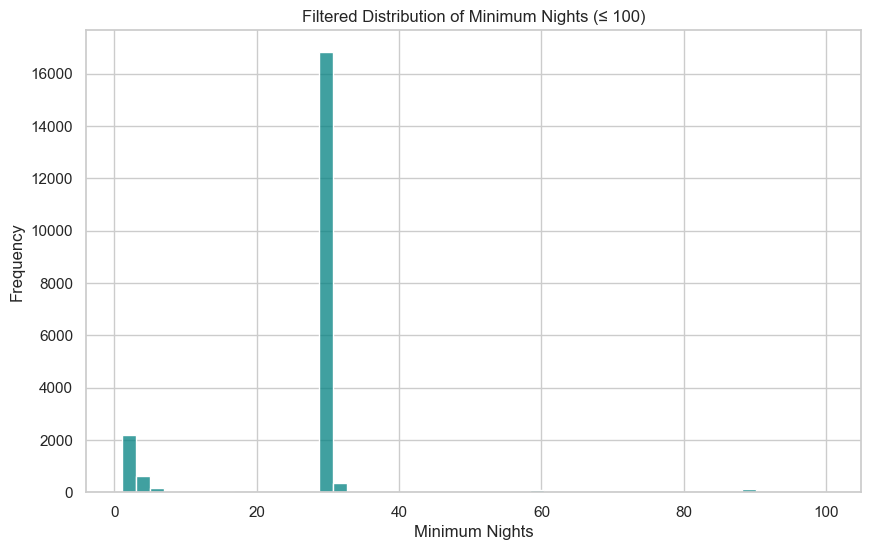

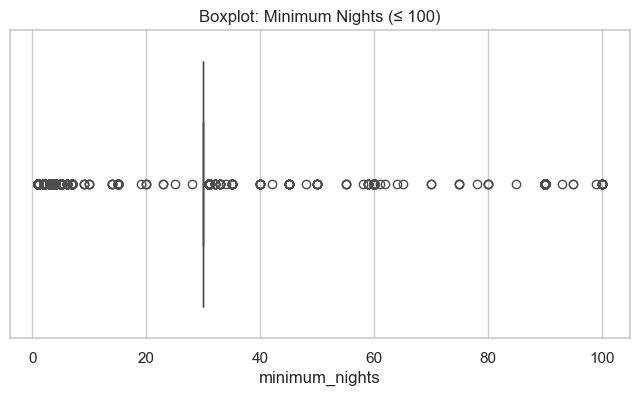

In [18]:
# Filter out extreme outliers for better visualizations

filtered_nights_df = df[df['minimum_nights'] <= 100]

# Visualize the cleaned distribution

plt.figure(figsize=(10, 6))
sns.histplot(filtered_nights_df['minimum_nights'], bins=50, color='teal')
plt.title("Filtered Distribution of Minimum Nights (≤ 100)")
plt.xlabel("Minimum Nights")
plt.ylabel("Frequency")
plt.show()

# Optional: Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=filtered_nights_df['minimum_nights'], color='orange')
plt.title("Boxplot: Minimum Nights (≤ 100)")
plt.show()

In [20]:
filtered_nights_df['minimum_nights'].skew()

np.float64(0.12251497632616759)

### 🔎 Key Insights:
- Most listings require exactly 30 nights minimum → likely due to NYC regulations on short-term rentals.
- ery few hosts allow <30 nights, which can affect:
- Booking flexibility
- Target guest type (tourist vs. long-term)
- Outliers (up to 1250 nights) were removed as they are not representative and distort the analysis.

## Univariate Analysis: number_of_reviews

In [21]:
df['number_of_reviews'].describe()

count    20736.000000
mean        42.586179
std         73.521954
min          1.000000
25%          4.000000
50%         14.000000
75%         49.000000
max       1865.000000
Name: number_of_reviews, dtype: float64

In [22]:
df['number_of_reviews'].skew()

np.float64(5.260564968396461)

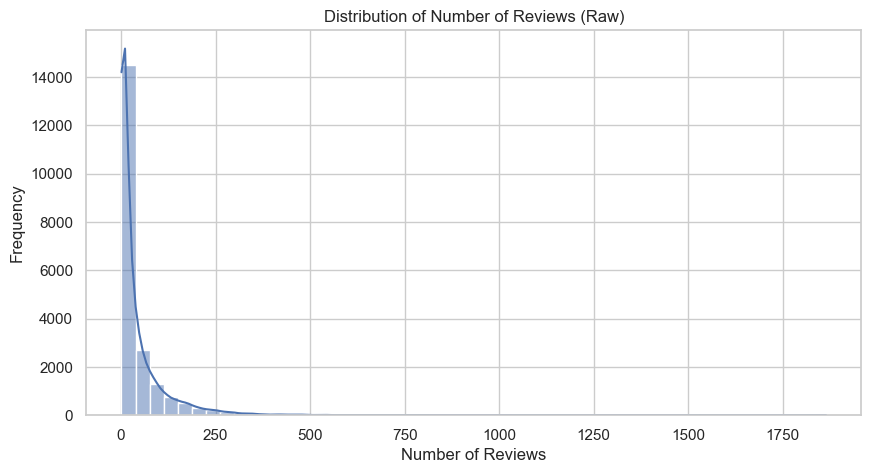

In [23]:
# Plot a histogram to see the raw distribution

plt.figure(figsize=(10, 5))
sns.histplot(df['number_of_reviews'], bins=50, kde=True)
plt.title('Distribution of Number of Reviews (Raw)')
plt.xlabel('Number of Reviews')
plt.ylabel('Frequency')
plt.show()

In [24]:
df['number_of_reviews'].max()

np.float64(1865.0)

In [25]:
filtered_reviews_df = df[df['number_of_reviews'] < 300]

In [26]:
filtered_reviews_df['number_of_reviews'].skew()

np.float64(2.2496156318311007)

In [27]:

df['log_reviews'] = np.log1p(filtered_reviews_df['number_of_reviews'])

In [29]:
df['log_reviews'].skew()

np.float64(0.15312471825835475)

#### ⚠️ Skewness Analysis:
- Original skewness: 5.26 → Highly right-skewed
- After removing outliers (<300): 2.25 → Still skewed, but reduced
- After log transformation: 0.15 → Almost normal

#### 📉 Insights from Histogram:
- Huge spike just after 0
- Extremely long tail after 250 reviews (negligible in number)
- Most listings have relatively few reviews

In [30]:
# to use raw values in some cases, you might cap the reviews at 300

df['capped_reviews'] = np.where(df['number_of_reviews'] > 300, 300, df['number_of_reviews'])

## Univariate analysis on Categorical data

Understand the distribution of each categorical column, detect dominant categories, and spot potential issues (e.g., too many unique values, missing data, sparse categories).

In [31]:
categorical_cols = df.select_dtypes(include='object').columns
print("Categorical columns:\n", categorical_cols)

Categorical columns:
 Index(['id', 'name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'license'],
      dtype='object')


🧩 Your Categorical Columns:
1.	id – 🛑 Skip this (unique identifier, not a feature).
2.	name – Optional (can analyze text length later, not needed now).
3.	host_name – High cardinality, skip basic plotting.
4.	neighbourhood_group – ✅ Primary location grouping.
5.	neighbourhood – ✅ Granular location, check top categories.
6.	room_type – ✅ Crucial for pricing/category insights.
7.	license – ✅ Often missing or has binary categories.

### room_type Distribution

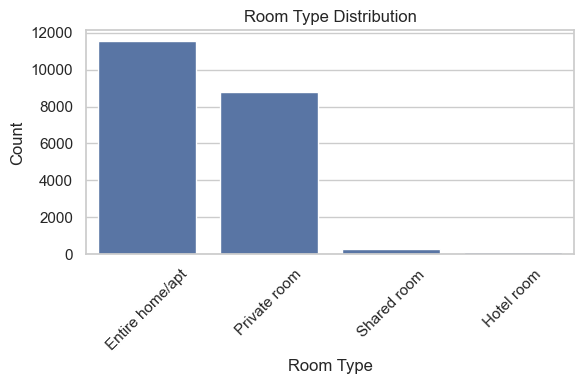

                 Count  Percentage
room_type                         
Entire home/apt  11541       55.66
Private room      8792       42.40
Shared room        291        1.40
Hotel room         112        0.54


In [33]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='room_type', order=df['room_type'].value_counts().index)
plt.title('Room Type Distribution')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Value counts with percentage
room_counts = df['room_type'].value_counts()
room_percent = df['room_type'].value_counts(normalize=True) * 100
room_summary = pd.DataFrame({'Count': room_counts, 'Percentage': room_percent.round(2)})
print(room_summary)

💡 Insights:
- Majority listings (55.66%) are entire apartments/homes – most common choice on Airbnb.
- Private rooms are the next most popular (42.4%) – likely more budget-friendly.
- Shared rooms and hotel rooms together make up less than 2% – very rare on the platform.
- We can explore how these affect price, availability, and reviews later in bivariate analysis.

### neighbourhood_group Distribution

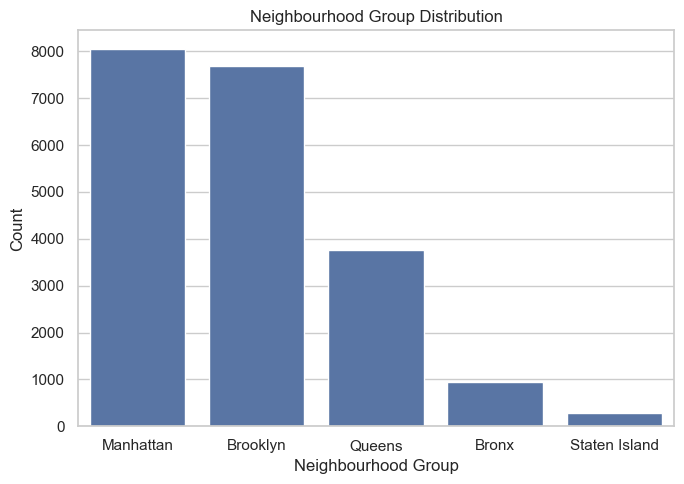

                     Count  Percentage
neighbourhood_group                   
Manhattan             8043       38.79
Brooklyn              7694       37.10
Queens                3759       18.13
Bronx                  949        4.58
Staten Island          291        1.40


In [34]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='neighbourhood_group', order=df['neighbourhood_group'].value_counts().index)
plt.title('Neighbourhood Group Distribution')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Count and percentage table
ng_counts = df['neighbourhood_group'].value_counts()
ng_percent = df['neighbourhood_group'].value_counts(normalize=True) * 100
ng_summary = pd.DataFrame({'Count': ng_counts, 'Percentage': ng_percent.round(2)})
print(ng_summary)

💡 Insights:
- Manhattan (38.79%) and Brooklyn (37.10%) together make up ~76% of all listings, dominating the market.
- Queens follows but has less than half the number of listings compared to Manhattan.
- Bronx and Staten Island are least represented, with minimal listings (~6% combined).
- This likely reflects both tourist demand and host density in these boroughs.

### neighbourhood Distribution

Since this column contains many unique values, we’ll visualize only the top 20 most common for clarity.

/var/folders/6q/mymvn81j1_d0f0htgctb3bmm0000gn/T/ipykernel_2348/1737172828.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neigh.values, y=top_neigh.index, palette='viridis')


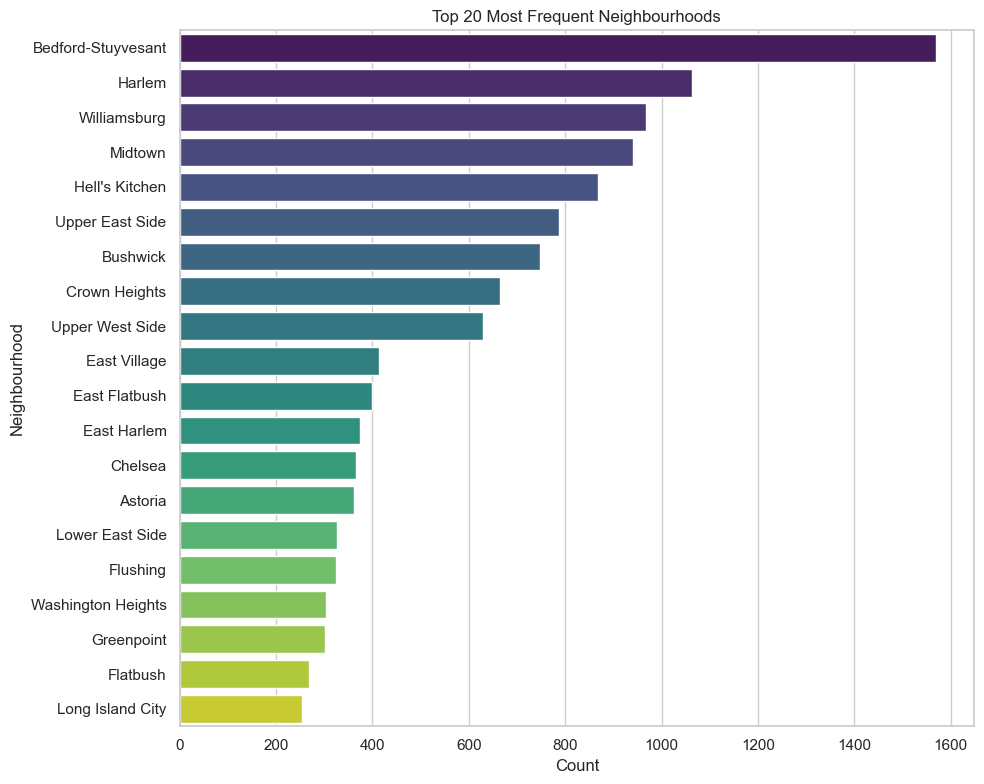

         Neighbourhood  Count  Percentage
0   Bedford-Stuyvesant   1570        7.57
1               Harlem   1064        5.13
2         Williamsburg    968        4.67
3              Midtown    940        4.53
4       Hell's Kitchen    869        4.19
5      Upper East Side    787        3.80
6             Bushwick    747        3.60
7        Crown Heights    664        3.20
8      Upper West Side    629        3.03
9         East Village    413        1.99
10       East Flatbush    399        1.92
11         East Harlem    375        1.81
12             Chelsea    366        1.77
13             Astoria    361        1.74
14     Lower East Side    327        1.58
15            Flushing    324        1.56
16  Washington Heights    303        1.46
17          Greenpoint    301        1.45
18            Flatbush    269        1.30
19    Long Island City    253        1.22


In [35]:
plt.figure(figsize=(10,8))
top_neigh = df['neighbourhood'].value_counts().head(20)
sns.barplot(x=top_neigh.values, y=top_neigh.index, palette='viridis')
plt.title('Top 20 Most Frequent Neighbourhoods')
plt.xlabel('Count')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.show()

# Tabular summary
top_neigh_df = top_neigh.reset_index()
top_neigh_df.columns = ['Neighbourhood', 'Count']
top_neigh_df['Percentage'] = (top_neigh_df['Count'] / df.shape[0] * 100).round(2)
print(top_neigh_df)

##### 🔍 Insights:
- Bedford-Stuyvesant leads as the most frequent listing neighbourhood, contributing 7.57% of all entries — a key hotspot in Brooklyn.
- Harlem, Williamsburg, and Midtown also show high listing densities, indicating strong tourist interest and host activity.
- Several Manhattan neighborhoods like Hell’s Kitchen, Chelsea, East Village, and Upper West Side make this list — aligning with Manhattan’s overall dominance.
- Presence of Astoria, Flushing, and Long Island City indicates growing popularity in Queens.
- Overall, the top 20 neighbourhoods account for a substantial share of listings, reflecting urban density and tourism trends.

### host_name (categorical but high cardinality)

Instead of analyzing all unique names, we’ll explore the top 10 most active hosts by listing count.

/var/folders/6q/mymvn81j1_d0f0htgctb3bmm0000gn/T/ipykernel_2348/2736670552.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_hosts.values, y=top_hosts.index, palette='coolwarm')


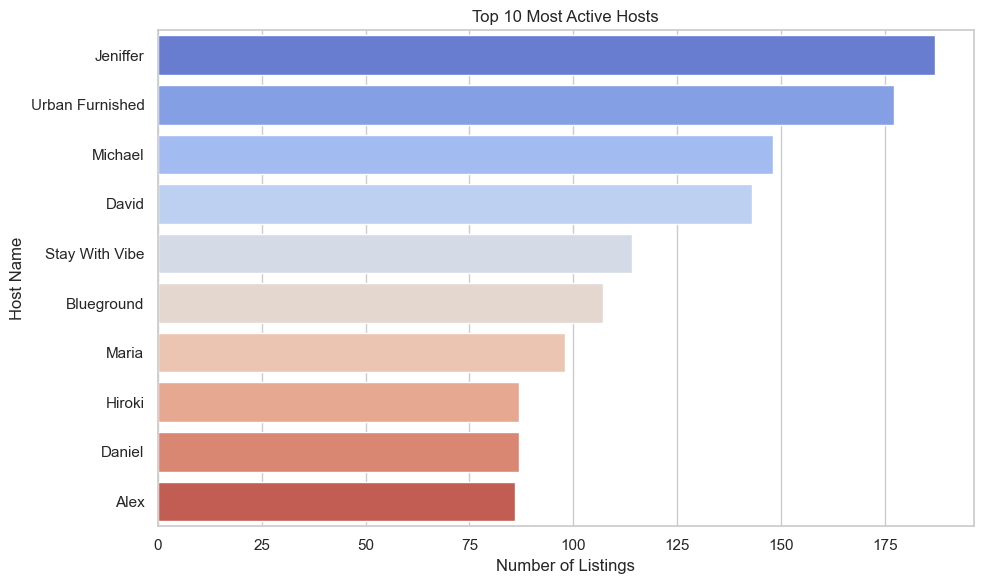

         Host Name  Count
0         Jeniffer    187
1  Urban Furnished    177
2          Michael    148
3            David    143
4   Stay With Vibe    114
5       Blueground    107
6            Maria     98
7           Hiroki     87
8           Daniel     87
9             Alex     86


In [36]:
top_hosts = df['host_name'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_hosts.values, y=top_hosts.index, palette='coolwarm')
plt.title('Top 10 Most Active Hosts')
plt.xlabel('Number of Listings')
plt.ylabel('Host Name')
plt.tight_layout()
plt.show()

# Tabular view
top_hosts_df = top_hosts.reset_index()
top_hosts_df.columns = ['Host Name', 'Count']
print(top_hosts_df)

#### 🔍 Insights:
- Jeniffer leads with the most listings at 187, followed closely by Urban Furnished (177) and Michael (148).
- Corporate-style hosts like Urban Furnished, Stay With Vibe, and Blueground indicate business-scaled rental operations.
- Others like David, Maria, and Daniel may reflect individuals managing multiple properties.
- These hosts might contribute significantly to the revenue and booking volume — worth exploring in multivariate analysis later.

### license column

In [37]:
license_counts = df['license'].value_counts(dropna=False)
license_counts_df = license_counts.reset_index()
license_counts_df.columns = ['License', 'Count']
license_counts_df['Percentage'] = round(100 * license_counts_df['Count'] / df.shape[0], 2)
print(license_counts_df)

                License  Count  Percentage
0            No License  17553       84.65
1                Exempt   2133       10.29
2    OSE-STRREG-0000068     14        0.07
3    OSE-STRREG-0000437      6        0.03
4    OSE-STRREG-0008664      6        0.03
..                  ...    ...         ...
872  OSE-STRREG-0000105      1        0.00
873  OSE-STRREG-0000300      1        0.00
874  OSE-STRREG-0000782      1        0.00
875  OSE-STRREG-0000142      1        0.00
876  OSE-STRREG-0000513      1        0.00

[877 rows x 3 columns]


#### 🔍 Insights:
- A huge majority (84.65%) of listings do not have a license.
- Around 10.29% are marked as “Exempt”, possibly legally not required to register.
- A small number of listings (≈ 5%) have actual license IDs (e.g., OSE-STRREG-0000068), which indicates regulatory compliance.
- Licensing data is highly skewed and sparse, making it a strong candidate for binary encoding (Licensed vs. Unlicensed/Exempt).
